# Lab 3 - Part 1: Text Visualization & Classical Representations


**Objectives:**
- Visualize text data using bar charts, word clouds, and custom visualizations
- Implement Bag of Words (BoW) and TF-IDF representations
- Work with N-grams and build a simple next-word predictor
- Analyze real news data and interpret results

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning
- Will be verified during an **oral defense session**

---

## Setup

In [1]:
# Install required libraries (uncomment if needed)
# !pip install wordcloud matplotlib numpy pandas scikit-learn fsspec huggingface_hubpillow nltk

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


---

## Part A: Loading and Exploring the 20 Newsgroups Dataset (15 min)

We will use the 20 Newsgroups dataset from Hugging Face. This dataset contains news articles from 20 different categories.

In [7]:
# Load the dataset
import pandas as pd
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}
## TODO: check on https://huggingface.co/datasets/SetFit/20_newsgroups how to load with pandas
df = pd.read_json("hf://datasets/SetFit/20_newsgroups/" + splits["train"], lines=True)
 # YOUR CODE HERE

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
sci.med                     594
rec.autos                   594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [8]:
# View sample data
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


### Exercise A.1: Select YOUR Categories

**Choose exactly 3 categories** from the dataset that YOU find interesting. This choice is personal and will affect all your subsequent analysis.

**Available categories:**
- alt.atheism, comp.graphics, ...

In [9]:
# TODO: Choose YOUR 3 categories (this affects all your analysis!)
# YOUR CODE HERE
my_categories = ["sci.space", "comp.graphics", "misc.forsale"] # Replace with your choices

# Filter the dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['sci.space', 'comp.graphics', 'misc.forsale']
Filtered dataset size: 1762

Distribution:
label_text
sci.space        593
misc.forsale     585
comp.graphics    584
Name: count, dtype: int64


### Written Question A.1 (Personal Interpretation)

**Why did you choose these 3 specific categories?** Explain your reasoning (at least 3 sentences).

Consider:
- Are they related or completely different?
- What do you expect to find in terms of vocabulary differences?
- Why are they interesting to YOU?

**YOUR ANSWER:**

*[Write your answer here - minimum 3 sentences]*

I chose these 3 categories because they each interest me in different ways. I have always liked everything related to space, I enjoy buying and selling things, and I find visual content and graphics interesting too. They are also very different from each other, which makes the analysis more interesting. On one side, sci.space will probably use very scientific words, comp.graphics will have more technical terms related to visuals, and misc.forsale will sound much more casual and informal (closer to everyday conversation). I think those differences will be easy to spot and will make the classification task more interesting.

---

## Part B: Text Preprocessing Function

Before visualization, we need to clean our text data.

In [10]:
# Example preprocessing function
# TODO: Complete the function as needed
import re
import string

def preprocess_text(text):
    """Basic text preprocessing."""
    # Lowercase
    text = text.lower() # YOUR CODE HERE
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text) # YOUR CODE HERE
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text) # YOUR CODE HERE
    # Remove numbers
    text = re.sub(r'\d+', '', text) # YOUR CODE HERE
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation)) # YOUR CODE HERE
    # Remove extra whitespace
    text = ' '.join(text.split()) # YOUR CODE HERE
    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


### Exercise B.1: Improve the Preprocessing Function

The function above is basic. **Improve it** by adding:
1. Stop word removal
2. Lemmatization
3. Minimum word length filter (remove words with < 3 characters)

In [12]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [13]:
# TODO: Complete this improved preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop words removal and lemmatization.

    Args:
        text (str): Input text
    Returns:
        str: Preprocessed text
    """
    # YOUR CODE HERE
    # Step 1: Basic cleaning (lowercase, remove emails, URLs, numbers, punctuation)
    text = preprocess_text(text)

    # Step 2: Tokenize
    tokens = word_tokenize(text)

    # Step 3: Remove stop words
    tokens = [t for t in tokens if t not in stop_words]

    # Step 4: Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # Step 5: Remove short words (< 3 chars)
    tokens = [t for t in tokens if len(t) >= 3]

    # Step 6: Join back to string
    text = ' '.join(tokens)

    return text

# Test your function
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [14]:
# Apply preprocessing to your filtered dataset
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
weiteks addressphone number like get information chip


---

## Part C: Text Visualization

### C.1 Bar Chart: Top Words per Category

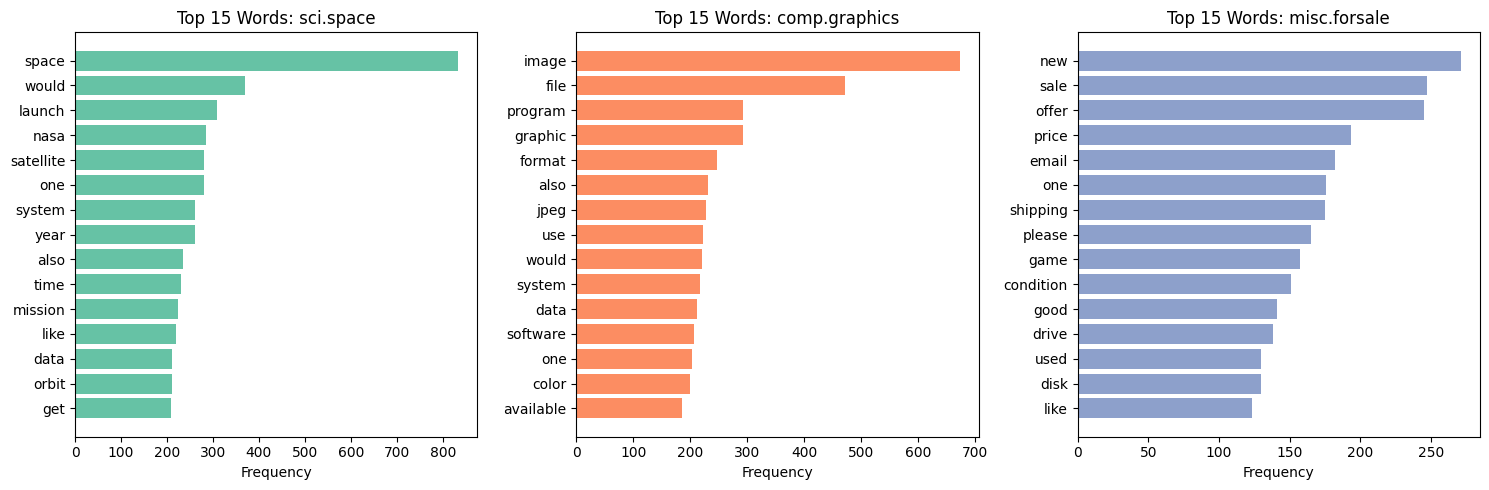

In [15]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)

    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Look at your bar charts above and answer:

1. **What words are UNIQUE to each category?** (List at least 2 per category)
2. **What words are SHARED across categories?** Why do you think they appear in multiple categories?
3. **Based ONLY on the top words, could you guess the topic of each category?** Explain.

**YOUR ANSWER:**

*Category 1 (sci.space):*
- Unique words: ...
- space, nasa, launch, satellite, orbit, mission

*Category 2 (comp.graphics):*
- Unique words: ...
- image, jpeg, graphic, color, format

*Category 3 (misc.forsale):*
- Unique words: ...
-  sale, offer, price, shipping, condition

*Shared words and explanation:*
Words like one, would, also, data, system, like use appear in multiple categories. This makes sense because they are very general words that people use in any kind of writing, even after removing stop words. For example system appears in both comp.graphics and sci.space because both talk about technical systems. Data also shows up in both for similar reasons.

*Topic guessing analysis:*
Yes. sci.space is very easy to identify because words like nasa, orbit, satellite and mission are extremely specific. comp.graphics is also pretty clear with image, jpeg, graphic and color. misc.forsale is the most obvious of all because words like sale, price, shipping and condition immediately suggest a marketplace. The vocabulary differences are very clear and that is actually a good sign for classification, it means the model should have an easy time telling these three categories apart.

### C.2 Word Clouds

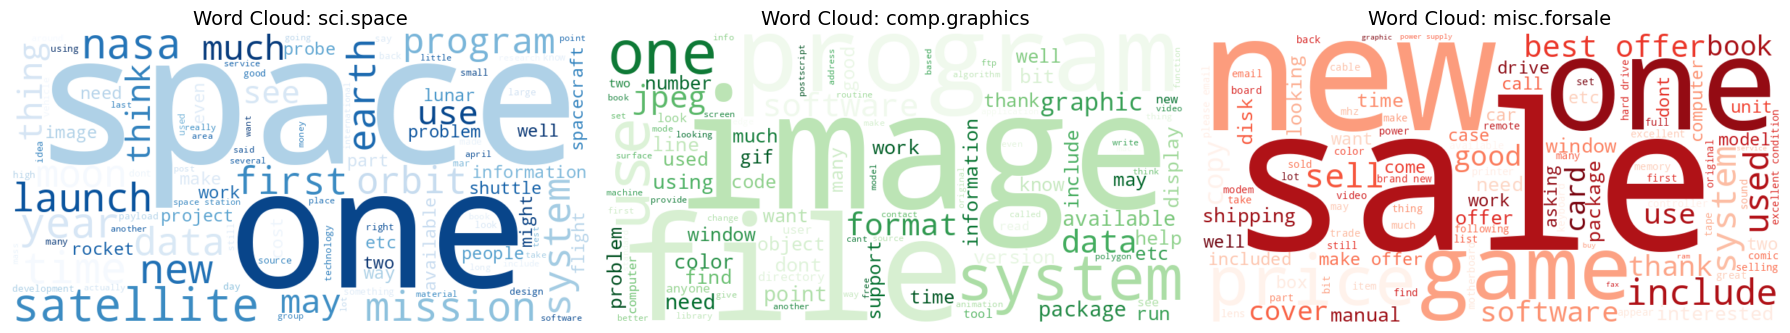

In [16]:
# Simple word cloud for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

Create a word cloud using a **custom mask image**.

**Instructions:**
1. Find or create a simple black & white silhouette image (PNG format)
2. Save it in your working directory
3. Use it as a mask for your word cloud

**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

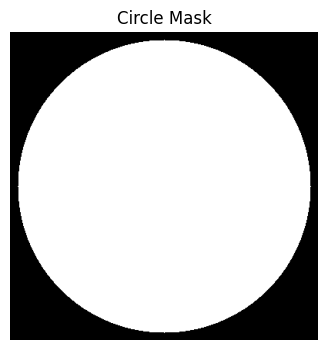

In [17]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

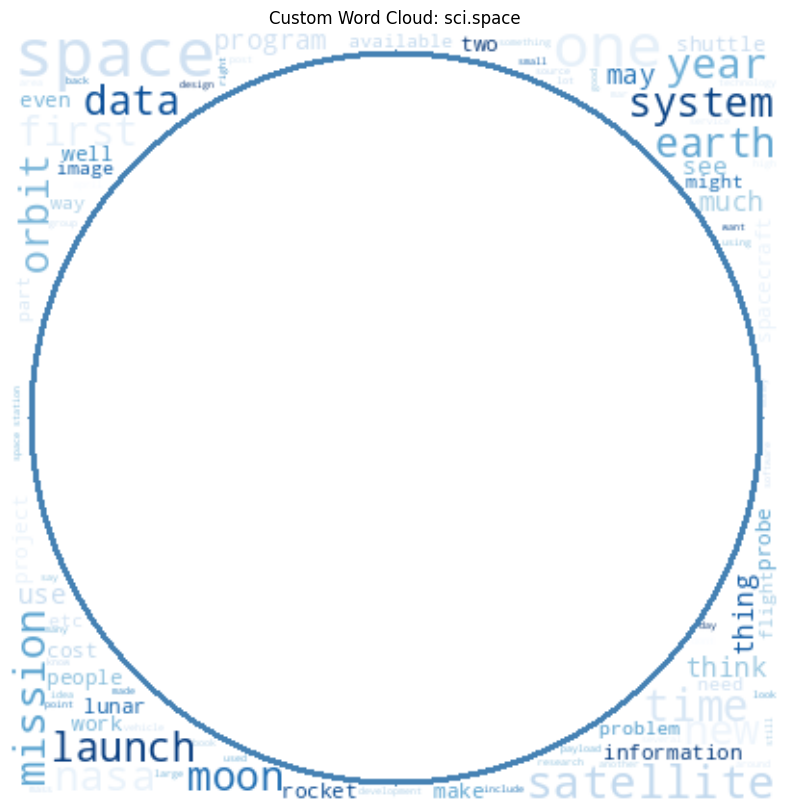

In [18]:
# TODO: Create a custom word cloud with a mask
# Choose ONE of your categories for this visualization

# YOUR CODE HERE
selected_category = "sci.space"  # Choose one of your categories

# Get texts for selected category
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

# Create word cloud with mask
# Hint: Use the mask parameter in WordCloud()
# wordcloud = WordCloud(..., mask=your_mask, ...).generate(text_combined)

wordcloud_masked = WordCloud(  # YOUR CODE HERE
    width=400,
    height=400,
    background_color='white',
    mask=circle_mask,
    contour_width=2,
    contour_color='steelblue',
    colormap='Blues',
    max_words=100
).generate(text_combined)

# Display
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud_masked, interpolation='bilinear')  # YOUR CODE HERE - display the wordcloud
plt.title(f'Custom Word Cloud: {selected_category}')
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part D: Bag of Words (BoW) Representation

In [ ]:
# Example: Simple Bag of Words
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Create BoW vectorizer
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# Show vocabulary
print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

# As DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

### Exercise D.1: Create BoW for Your Dataset

In [19]:
# TODO: Create a Bag of Words representation for your filtered dataset
# Use parameters: max_features=1000, min_df=5, max_df=0.95

# YOUR CODE HERE
bow_vectorizer_full = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

# Fit and transform on your cleaned texts
bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])  # YOUR CODE HERE

print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")

BoW Matrix shape: (1762, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['able' 'access' 'act' 'activity' 'actually' 'add' 'added' 'addition'
 'additional' 'address' 'advance' 'advanced' 'advertising' 'aerospace'
 'age' 'agency' 'ago' 'air' 'aircraft' 'algorithm']


### Exercise D.2: Document Similarity with BoW

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

# TODO: Compute cosine similarity between documents
# Then find the 2 most similar documents and the 2 most different documents

# Compute similarity matrix
similarity_matrix = cosine_similarity(bow_matrix_full)  # YOUR CODE HERE

print(f"Similarity matrix shape: {similarity_matrix.shape}")

Similarity matrix shape: (1762, 1762)


In [21]:
# TODO: Find the 2 most similar documents (excluding self-similarity)
# Hint: Set diagonal to 0 or -1, then find argmax

# YOUR CODE HERE
sim_matrix_no_diag = similarity_matrix.copy()
np.fill_diagonal(sim_matrix_no_diag, 0)
most_similar_flat = np.argmax(sim_matrix_no_diag)
idx1, idx2 = np.unravel_index(most_similar_flat, sim_matrix_no_diag.shape)

# Find indices of most similar pair
most_similar_idx = (idx1, idx2)  # (idx1, idx2)
most_similar_score = sim_matrix_no_diag[idx1, idx2]

print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score}")
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

Most similar documents: (np.int64(235), np.int64(1147))
Similarity score: 1.0000000000000009

Document 1 category: misc.forsale
Document 2 category: misc.forsale


### Written Question D.1 (Personal Interpretation)

Look at the 2 most similar documents you found:

1. **Are they from the same category or different categories?**
2. **Read the original texts (first 200 characters). What makes them similar?**
3. **Is the BoW similarity measure meaningful here? Why or why not?**

In [22]:
# Show the similar documents for your analysis
print("Document 1 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[0]]['text'][:300])
print("\n" + "="*50 + "\n")
print("Document 2 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[1]]['text'][:300])

Document 1 (first 300 chars):
SOMEONE PLEASE BUY THESE BOOKS!!!!!  I AM NOT ASKING MUCH!!!!!!

JUST MAKE ME AN OFFER AND I WILL PROBABLY TAKE IT!!!!!

* Calculus w/ Analytic Geometry by Authur B. Simon (copyright date 1982), below avg condition but still readable! 

* Writing good software in Fortran, Graham Smith. 

* The Holt 


Document 2 (first 300 chars):
SOMEONE PLEASE BUY THESE BOOKS!!!!!  I AM NOT ASKING MUCH!!!!!!

JUST MAKE ME AN OFFER AND I WILL PROBABLY TAKE IT!!!!!

* Calculus w/ Analytic Geometry by Authur B. Simon (copyright date 1982), below avg condition but still readable! 

* Writing good software in Fortran, Graham Smith. 

* The Holt 


**YOUR ANSWER:**

*[Write your analysis here - answer all 3 questions]*

1. Same or different category:
Yes, both are from the same category (misc.forsale)

2. What makes them similar:
They are literally the exact same post: same words, same structure, same content. Looks like a duplicated entry in the dataset, which is why the similarity score was exactly 1

3. Is BoW meaningful here: Yes, is meaningful here in the sense that it correctly detected two identical documents. However this is not a very interesting finding since it just found a duplicate, not two genuinely similar but different posts.

---

## Part E: TF-IDF Representation

In [23]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

TF-IDF Matrix:


,deep,great,is,learning,love,machine,too
0,0.000,0.000,0.000,0.481,0.620,0.620,0.000
1,0.000,0.584,0.584,0.345,0.000,0.445,0.000
2,0.584,0.000,0.000,0.345,0.445,0.000,0.584


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow_vectorizer.get_feature_names_out()
)

# NEW***

In [26]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

Word 'learning' scores:
  BoW:    [1, 1, 1]
  TF-IDF: [0.481, 0.345, 0.345]

Notice: TF-IDF gives LOWER scores to common words!


### Exercise E.1: TF-IDF Analysis

In [28]:
# TODO: Create TF-IDF representation for your dataset
# Use same parameters: max_features=1000, min_df=5, max_df=0.95

tfidf_vectorizer_full = TfidfVectorizer(
    max_features=1000,  # YOUR PARAMETERS HERE
    min_df=5,
    max_df=0.95
)

tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text_clean'])  # YOUR CODE HERE

print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")

TF-IDF Matrix shape: (1762, 1000)


In [29]:
# TODO: Find the top 10 most important words (highest TF-IDF) for each of your 3 categories

def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""
    # YOUR CODE HERE
    # 1. Get indices of documents in this category
    category_indices = df_filtered[df_filtered['label_text'] == category].index.tolist()
    # 2. Get their TF-IDF vectors
    category_matrix = tfidf_matrix_full[category_indices]
    # 3. Compute mean TF-IDF for each word across these documents
    mean_tfidf = category_matrix.mean(axis=0).A1
    # 4. Return top n words
    feature_names = tfidf_vectorizer_full.get_feature_names_out()
    top_indices = mean_tfidf.argsort()[::-1][:n]
    return list(zip(feature_names[top_indices], mean_tfidf[top_indices].round(4)))

# Display top words for each category
for category in my_categories:
    top_words = get_top_tfidf_words(category, 10)
    print(f"\nTop TF-IDF words for '{category}':")
    print(top_words)


Top TF-IDF words for 'sci.space':
[('space', np.float64(0.0586)), ('would', np.float64(0.0409)), ('one', np.float64(0.0282)), ('like', np.float64(0.0275)), ('nasa', np.float64(0.0239)), ('think', np.float64(0.0238)), ('launch', np.float64(0.0237)), ('get', np.float64(0.0233)), ('orbit', np.float64(0.0231)), ('could', np.float64(0.0224))]

Top TF-IDF words for 'comp.graphics':
[('file', np.float64(0.0509)), ('image', np.float64(0.0398)), ('graphic', np.float64(0.0374)), ('thanks', np.float64(0.0352)), ('know', np.float64(0.033)), ('anyone', np.float64(0.0303)), ('would', np.float64(0.0302)), ('program', np.float64(0.0301)), ('format', np.float64(0.0259)), ('help', np.float64(0.0254))]

Top TF-IDF words for 'misc.forsale':
[('sale', np.float64(0.0574)), ('offer', np.float64(0.0508)), ('new', np.float64(0.0412)), ('email', np.float64(0.0379)), ('shipping', np.float64(0.0373)), ('condition', np.float64(0.0348)), ('please', np.float64(0.0329)), ('price', np.float64(0.0329)), ('drive', np.f

### Written Question E.1 (Personal Interpretation)

Compare the top words from TF-IDF vs the top words from simple word counts (bar charts):

1. **What words appear in TF-IDF top 10 but NOT in the word count top 15?**
2. **What words appear in word count top 15 but NOT in TF-IDF top 10?**
3. **Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.**

**YOUR ANSWER:**

*[Write your comparative analysis here]*

1. Words in TF-IDF but not counts:
sci.space: think, could.
comp.graphics: thanks, know, anyone, help.
misc.forsale: email, please, drive, game.

2. Words in counts but not TF-IDF:
sci.space: data, time, also, year, system, mission.
comp.graphics: use, also, data, software, color, one.
misc.forsale: one, used, disk, like, good.

3. Which method is better and why:

TF-IDF is clearly better. For example in sci.space, BoW ranked would, one, also very high just because they appear frequently, but those words tell us nothing about space. TF-IDF keeps words like nasa, orbit, launch higher because they are unique to that category. The same happens with misc.forsale where TF-IDF highlights sale, offer, shipping, condition which are much more descriptive than generic words like one or like. In conclusion TF-IDF filters out noise and keeps the words that actually define the topic.

---

## Part F: N-grams and Next Word Prediction

In [30]:
# Example: Extracting N-grams
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:", bigrams)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("Trigrams:", trigrams)

Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', 'and'), ('and', 'machine'), ('machine', 'learning')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing'), ('language', 'processing', 'and'), ('processing', 'and', 'machine'), ('and', 'machine', 'learning')]


In [31]:
# Using CountVectorizer for n-grams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # Unigrams, bigrams, and trigrams

sample_docs = ["I love machine learning", "Machine learning is great"]

bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

Bigram features: ['is great' 'learning is' 'love machine' 'machine learning']


### Exercise F.1: Analyze Bigrams in Your Dataset

In [32]:
# TODO: Find the top 15 most common bigrams for each of your categories

bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=500,
    min_df=3
)

# YOUR CODE HERE
# For each category:
# 1. Get the texts
# 2. Fit the bigram vectorizer
# 3. Find most common bigrams

for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()

    # YOUR CODE HERE
    bigram_matrix = bigram_vectorizer.fit_transform(texts)
    feature_names = bigram_vectorizer.get_feature_names_out()
    counts = bigram_matrix.sum(axis=0).A1
    top_indices = counts.argsort()[::-1][:15]
    top_bigrams = [(feature_names[i], counts[i]) for i in top_indices]

    print(f"\nTop bigrams for '{category}':")
    for bigram, count in top_bigrams[:15]:
        print(f"  {bigram}: {count}")


Top bigrams for 'sci.space':
  space station: 69
  space shuttle: 56
  anonymous ftp: 37
  commercial space: 31
  remote sensing: 30
  launch vehicle: 27
  national space: 26
  nasa ames: 24
  air force: 23
  space technology: 21
  space program: 20
  anyone know: 20
  launch system: 20
  black hole: 20
  dont know: 19

Top bigrams for 'comp.graphics':
  image processing: 54
  file format: 42
  computer graphic: 41
  thanks advance: 38
  would like: 38
  source code: 35
  anyone know: 35
  dont know: 32
  anonymous ftp: 30
  ray tracer: 29
  virtual reality: 28
  ftp site: 27
  image file: 25
  bit image: 24
  image quality: 21

Top bigrams for 'misc.forsale':
  best offer: 87
  make offer: 62
  would like: 48
  brand new: 47
  excellent condition: 42
  please email: 39
  hard drive: 38
  power supply: 31
  ghost rider: 29
  year old: 28
  picture sleeve: 26
  interested please: 25
  pay shipping: 24
  plus shipping: 21
  please contact: 21


### Exercise F.2: Simple Next Word Predictor

Build a simple next-word predictor using bigram probabilities.

In [33]:
# TODO: Build a bigram-based next word predictor

class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}  # {word1: {word2: count, word3: count, ...}}
        self.unigram_counts = {}  # {word: count}

    def train(self, texts):
        """
        Train the model on a list of texts.

        Args:
            texts (list): List of preprocessed text strings
        """
        # YOUR CODE HERE
        # 1. For each text, tokenize into words
        for text in texts:
            words = text.split()
            # 2. Count unigrams
            for word in words:
                self.unigram_counts[word] = self.unigram_counts.get(word, 0) + 1
            # 3. Count bigrams (word pairs)
            for i in range(len(words) - 1):
                word1, word2 = words[i], words[i + 1]
                if word1 not in self.bigram_counts:
                    self.bigram_counts[word1] = {}
                self.bigram_counts[word1][word2] = self.bigram_counts[word1].get(word2, 0) + 1

    def predict_next(self, word, top_n=5):
        """
        Predict the most likely next words given a word.

        Args:
            word (str): The input word
            top_n (int): Number of predictions to return

        Returns:
            list: List of (next_word, probability) tuples
        """
        # YOUR CODE HERE
        # 1. Look up the word in bigram_counts
        if word not in self.bigram_counts:
            return []
        # 2. Calculate probabilities: P(word2|word1) = count(word1, word2) / count(word1)
        total = self.unigram_counts[word]
        predictions = [
            (word2, count / total)
            for word2, count in self.bigram_counts[word].items()
        ]
        # 3. Return top_n predictions sorted by probability
        return sorted(predictions, key=lambda x: x[1], reverse=True)[:top_n]

# Train on your dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())

In [34]:
# Test your predictor with words relevant to your categories
# TODO: Choose 5 test words that are relevant to YOUR chosen categories

test_words = ["space", "image", "sale", "launch", "file"]  # Replace with your words

print("Next Word Predictions:")
print("=" * 40)

for word in test_words:
    predictions = predictor.predict_next(word.lower(), top_n=5)
    print(f"\n'{word}' ->")
    for next_word, prob in predictions:
        print(f"  {next_word}: {prob:.3f}")

Next Word Predictions:

'space' ->
  station: 0.077
  shuttle: 0.065
  technology: 0.023
  program: 0.023
  science: 0.021

'image' ->
  processing: 0.074
  file: 0.032
  format: 0.028
  quality: 0.027
  analysis: 0.019

'sale' ->
  trade: 0.028
  excellent: 0.021
  price: 0.018
  brand: 0.014
  come: 0.014

'launch' ->
  vehicle: 0.087
  system: 0.064
  service: 0.048
  site: 0.038
  pad: 0.029

'file' ->
  format: 0.079
  use: 0.011
  available: 0.011
  size: 0.011
  disclaims: 0.009


### Written Question F.1 (Personal Interpretation)

Analyze your next-word predictor results:

1. **Were the predictions sensible?** Give 2 examples of good predictions and 2 examples of bad predictions.
2. **What are the limitations of this simple bigram model?**
3. **How could you improve this predictor?** (List at least 3 ideas)

**YOUR ANSWER:**

1. Good predictions:
   - space followed by station and shuttle make total sense since these are very common phrases in a space discussion context
   - launch followed by vehicle and image followed by processing are very natural and expected word combinations

   Bad predictions:
   - sale followed by come makes no sense since nobody writes that in a for sale post
   - file followed by disclaims is clearly a leftover from email signatures or legal text in the dataset, not a meaningful prediction at all

2. Limitations: The model only looks at 1 previous word so it has no understanding of context or sentence structure. Rare word combinations have very low counts so probabilities are unreliable. It also cannot handle words it has never seen before and has no understanding of actual meaning.

3. Improvement ideas:
   - Use trigrams or larger n-grams to consider more context instead of just 1 previous word
   - Apply smoothing techniques like Laplace smoothing to handle rare or unseen word combinations better
   - Use a neural language model like an LSTM or transformer to capture long-range dependencies and actual meaning

---

## Part G: Document Correlation Matrix

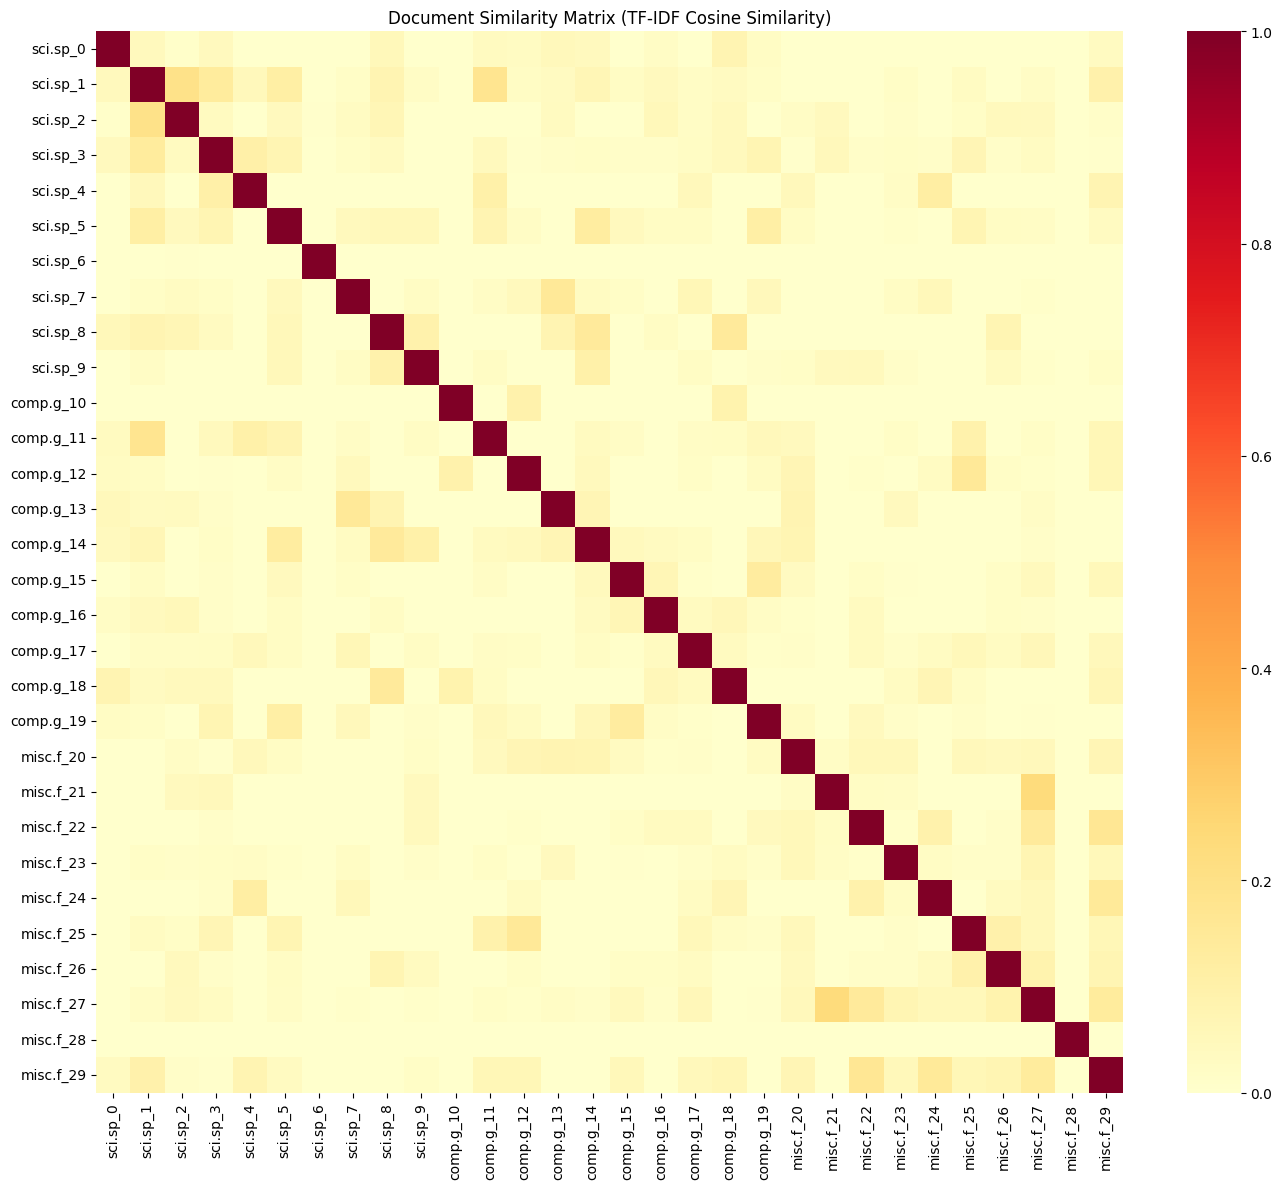

In [35]:
# TODO: Create a correlation/similarity heatmap between documents
# Sample 10 documents from each of your 3 categories (30 total)

import seaborn as sns

# Sample documents
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Create TF-IDF for sampled documents
tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

# Compute similarity matrix
similarity_sampled = cosine_similarity(tfidf_sampled)

# Create labels for heatmap
labels = [f"{cat[:6]}_{i}" for cat, i in zip(df_sampled['label_text'], range(len(df_sampled)))]

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled,
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False
)
plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)')
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question G.1 (Personal Interpretation)

Analyze the similarity heatmap:

1. **Do documents from the same category cluster together?** (i.e., do you see bright squares along the diagonal for each category group?)
2. **Which pair of categories is MOST similar to each other?** Which is LEAST similar?
3. **Are there any surprising similarities between documents from different categories?** If yes, what might explain this?

**YOUR ANSWER:**


   1. Clustering observation: Yes, documents from the same category clearly cluster together. 3 distinct  red blocks along the diagonal, 1 for sci.space (documents 0-9), 1 for comp.graphics (documents 10-19), and 1 for misc.forsale (documents 20-29). Outside these blocks almost everything is light yellow indicating very low similarity.

   2. Most/Least similar category pairs: The most similar pair appears to be sci.space and comp.graphics since there are a few slightly warmer spots between them, probably because both use technical vocabulary like "system" and "data". The least similar pair is sci.space and misc.forsale since their vocabularies are completely different, 1 talks about rockets and orbits and the other about prices and shipping.

   3. Surprising similarities: There are a few isolated warmer spots between different categories, for example some sci.space documents show slight similarity with comp.graphics ones. This could be explained by shared technical words like "system", "data" or "program" that appear in both categories even after TF-IDF weighting. Overall though there are no major surprises, the categories are very well separated.

---

## Summary - Part 1

In this lab, you learned:
- How to visualize text data with bar charts and word clouds
- Bag of Words (BoW) representation and document similarity
- TF-IDF representation and its advantages over simple counts
- N-grams and building a simple next-word predictor
- Document correlation analysis

---

## Submission Checklist - Part 1

- [ ] All code exercises completed
- [ ] All written questions answered (with YOUR personal interpretation)
- [ ] Visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Continue to Part 2 for Word Embeddings
